<a href="https://colab.research.google.com/github/momo25bend/streamsentinel/blob/main/streamsentinel_J1_fondations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers roboflow supervision opencv-python-headless

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Appareil utilisé :", device)

Appareil utilisé : cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/streamsentinel"
DOSSIERS = {k: f"{BASE}/{k}" for k in ["photos", "masques", "resultats"]}
for d in DOSSIERS.values():
    os.makedirs(d, exist_ok=True)
print(DOSSIERS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'photos': '/content/drive/MyDrive/streamsentinel/photos', 'masques': '/content/drive/MyDrive/streamsentinel/masques', 'resultats': '/content/drive/MyDrive/streamsentinel/resultats'}


In [ ]:
from google.colab import userdata
ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")
print("Clé chargée :", bool(ROBOFLOW_API_KEY))

Clé chargée : True


In [ ]:
!pip install -q roboflow

from roboflow import Roboflow
import glob,random,shutil,os

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
projet = rf.workspace("rf100-vl").project("floating-waste-8deje-lrbq")

dechets = None
for v in [1,2,3]:
  try:
    dechets = projet.version(v).download("yolov8",location="/content/datasets/dechets")
    print("version utilisée :" , v)
    break
  except Exception as e :
    print(f"Version{v}indisponible:",e)

images = glob.glob("/content/datasets/dechets/**/*.jpg",recursive=True)
print(len(images),"images téléchargées")

random.seed(0)
for i, p in enumerate(random.sample(images,min(30,len(images)))):
  shutil.copy(p,f"{DOSSIERS['photos']}/dechets_{i:03d}.jpg")
  print(len(os.listdir(DOSSIERS['photos'])),"photos dans le dossier")


loading Roboflow workspace...
loading Roboflow project...
Version1indisponible: Version number 1 is not found.
version utilisée : 2
2934 images téléchargées
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier
50 photos dans le dossier


In [ ]:
import requests, os

ENTETES = {"User-Agent": "StreamSentinel-hackathon/0.1 (projet etudiant)"}
API = "https://commons.wikimedia.org/w/api.php"

def retelecharger(requete, nom_fichier, decalage=3):
    params = {"action": "query", "format": "json", "generator": "search",
              "gsrsearch": f"{requete} filetype:bitmap", "gsrnamespace": 6, "gsrlimit": 12,
              "prop": "imageinfo", "iiprop": "url|mime", "iiurlwidth": 1024}
    pages = requests.get(API, params=params, headers=ENTETES, timeout=30).json()
    pages = sorted(pages.get("query", {}).get("pages", {}).values(), key=lambda p: p.get("index", 0))
    candidats = [p["imageinfo"][0] for p in pages if p.get("imageinfo", [{}])[0].get("mime") == "image/jpeg"]

    for info in candidats[decalage:]:
        contenu = requests.get(info.get("thumburl", info["url"]), headers=ENTETES, timeout=60).content
        chemin = f"{DOSSIERS["photos"]}/{nom_fichier}"
        with open(chemin, "wb") as f:
            f.write(contenu)
        try:
            charger(chemin)          # on vérifie que l'image s'ouvre vraiment
            print("OK :", nom_fichier, "→", info.get("descriptionurl", ""))
            return
        except Exception:
            if os.path.exists(chemin):
                os.remove(chemin)
    print("Échec :", nom_fichier)

retelecharger("algal bloom river", "eau_verte_01.jpg")
retelecharger("muddy river water", "eau_boueuse_01.jpg")
retelecharger("small stream forest", "berge_naturelle_02.jpg")

OK : eau_verte_01.jpg → https://commons.wikimedia.org/wiki/File:%D0%A6%D0%B2%D1%96%D1%82%D1%96%D0%BD%D0%BD%D1%8F_%D0%B2%D0%BE%D0%B4%D0%B8_%D0%B2_%D1%80%D1%96%D1%87%D1%86%D1%96_%D0%94%D0%BD%D1%96%D0%BF%D1%80%D0%BE._Algal_bloom_in_Dnipro_river.jpg
OK : eau_boueuse_01.jpg → https://commons.wikimedia.org/wiki/File:Flooded_banks_in_the_muddy_water_of_the_Mekong_with_a_boy,_rowing_in_a_repurposed_refrigerator_raft,_in_Don_Khon,_Laos.jpg
OK : berge_naturelle_02.jpg → https://commons.wikimedia.org/wiki/File:Small_stream_through_the_Hafren_Forest_-_geograph.org.uk_-_2982783.jpg


In [ ]:
import requests, csv, time, re, os, cv2

ENTETES = {"User-Agent": "StreamSentinel-hackathon/0.1 (projet etudiant)"}
API = "https://commons.wikimedia.org/w/api.php"

RECHERCHES = {
    "eau_verte":       "algal bloom river",
    "eau_boueuse":     "muddy river",
    "mousse":          "foam river pollution",
    "berge_betonnee":  "concrete river channel city",
    "berge_naturelle": "small river forest",
    "sans_eau":        "parking lot",
}

def telecharger_commons(requete, prefixe, nb=3):
    params = {
        "action": "query", "format": "json",
        "generator": "search", "gsrsearch": f"{requete} filetype:bitmap",
        "gsrnamespace": 6, "gsrlimit": nb * 4,
        "prop": "imageinfo", "iiprop": "url|mime|extmetadata", "iiurlwidth": 1024,
    }
    reponse = requests.get(API, params=params, headers=ENTETES, timeout=30).json()
    pages = sorted(reponse.get("query", {}).get("pages", {}).values(), key=lambda p: p.get("index", 0))

    credits = []
    for page in pages:
        if len(credits) >= nb:
            break
        info = page.get("imageinfo", [{}])[0]
        if info.get("mime") != "image/jpeg":
            continue
        meta = info.get("extmetadata", {})
        chemin = f"{DOSSIERS['photos']}/{prefixe}_{len(credits):02d}.jpg"
        image = requests.get(info.get("thumburl", info["url"]), headers=ENTETES, timeout=60).content
        with open(chemin, "wb") as f:
            f.write(image)
        auteur = re.sub("<[^>]+>", "", meta.get("Artist", {}).get("value", ""))
        credits.append({"fichier": os.path.basename(chemin),
                        "source": info.get("descriptionurl"),
                        "auteur": auteur.strip(),
                        "licence": meta.get("LicenseShortName", {}).get("value", "")})
        time.sleep(0.5)
    print(f"{prefixe} : {len(credits)} photos")
    return credits

tous_credits = []
for prefixe, requete in RECHERCHES.items():
    tous_credits += telecharger_commons(requete, prefixe)

# Photos volontairement ratées pour tester le contrôle qualité
source = cv2.imread(f"{DOSSIERS['photos']}/berge_naturelle_00.jpg")
if source is not None:
    cv2.imwrite(f"{DOSSIERS['photos']}/rate_flou.jpg", cv2.GaussianBlur(source, (41, 41), 0))
    cv2.imwrite(f"{DOSSIERS['photos']}/rate_sombre.jpg", (source * 0.12).astype("uint8"))
    print("2 photos ratées créées")

# Sauvegarde des crédits pour le README
with open(f"{BASE}/credits_photos.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["fichier", "source", "auteur", "licence"])
    writer.writeheader()
    writer.writerows(tous_credits)

print(len(os.listdir(DOSSIERS["photos"])), "photos au total dans le dossier")

eau_verte : 3 photos
eau_boueuse : 3 photos
mousse : 3 photos
berge_betonnee : 3 photos
berge_naturelle : 3 photos
sans_eau : 3 photos
2 photos ratées créées
51 photos au total dans le dossier


In [ ]:
import glob
import cv2
import numpy as np
from PIL import Image, ImageOps

EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
photos = sorted(p for ext in EXTENSIONS for p in glob.glob(f"{DOSSIERS['photos']}/{ext}"))
print(len(photos), "photos trouvées")

TAILLE_MAX = 1024  # on redimensionne pour avoir des mesures comparables entre photos

def charger(chemin):
    img = ImageOps.exif_transpose(Image.open(chemin)).convert("RGB")  # respecte l'orientation du téléphone
    img.thumbnail((TAILLE_MAX, TAILLE_MAX))
    return img

51 photos trouvées


In [ ]:
SEUIL_FLOU = 100      # variance du Laplacien : en dessous, image floue
SEUIL_SOMBRE = 50     # luminosité moyenne (0-255)
SEUIL_CLAIR = 210

def controle_qualite(img_pil):
    gris = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2GRAY)
    nettete = float(cv2.Laplacian(gris, cv2.CV_64F).var())
    luminosite = float(gris.mean())
    problemes = []
    if nettete < SEUIL_FLOU:
        problemes.append("Image floue : stabilisez le téléphone et refaites la photo.")
    if luminosite < SEUIL_SOMBRE:
        problemes.append("Image trop sombre : rapprochez-vous de la lumière ou activez le mode nuit.")
    if luminosite > SEUIL_CLAIR:
        problemes.append("Image surexposée : évitez de viser face au soleil.")
    return {"nettete": round(nettete, 1), "luminosite": round(luminosite, 1),
            "valide": not problemes, "problemes": problemes}

for p in photos[:5]:
    print(os.path.basename(p), controle_qualite(charger(p)))

berge_betonnee_00.jpg {'nettete': 326.5, 'luminosite': 140.4, 'valide': True, 'problemes': []}
berge_betonnee_01.jpg {'nettete': 361.2, 'luminosite': 126.0, 'valide': True, 'problemes': []}
berge_betonnee_02.jpg {'nettete': 1420.9, 'luminosite': 67.5, 'valide': True, 'problemes': []}
berge_naturelle_00.jpg {'nettete': 11956.9, 'luminosite': 140.9, 'valide': True, 'problemes': []}
berge_naturelle_01.jpg {'nettete': 12499.0, 'luminosite': 89.2, 'valide': True, 'problemes': []}


In [ ]:
for nom in ["rate_flou.jpg", "rate_sombre.jpg", "berge_naurelle_00.jpg"]:
  chemin = f"{DOSSIERS['photos']}/{nom}"
  if os.path.exists(chemin):
    print(nom,controle_qualite(charger(chemin)))

rate_flou.jpg {'nettete': 3.4, 'luminosite': 140.9, 'valide': False, 'problemes': ['Image floue : stabilisez le téléphone et refaites la photo.']}
rate_sombre.jpg {'nettete': 187.5, 'luminosite': 16.5, 'valide': False, 'problemes': ['Image trop sombre : rapprochez-vous de la lumière ou activez le mode nuit.']}


In [ ]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

MODEL_ID = "nvidia/segformer-b2-finetuned-ade-512-512"  # b0 = plus rapide, b4 = plus précis
processor = SegformerImageProcessor.from_pretrained(MODEL_ID)
seg_model = SegformerForSemanticSegmentation.from_pretrained(MODEL_ID).to(device).eval()
id2label = seg_model.config.id2label

GROUPES = {
    1: ("eau",         ["water", "sea", "river", "lake", "waterfall", "swimming pool"]),
    2: ("vegetation",  ["tree", "grass", "plant", "palm", "flower", "field"]),
    3: ("bati",        ["building", "wall", "house", "bridge", "road", "sidewalk", "fence",
                        "skyscraper", "railing", "column", "stairs", "pier", "car", "bench"]),
    4: ("sol_naturel", ["earth", "rock", "sand", "mountain", "hill", "dirt track"]),
    5: ("ciel",        ["sky"]),
}
NOMS_GROUPES = {0: "autre", **{g: nom for g, (nom, _) in GROUPES.items()}}

# Table de correspondance classe ADE20K -> groupe
table = np.zeros(len(id2label), dtype=np.uint8)
trouves = set()
for idx, nom in id2label.items():
    court = nom.split(";")[0].strip().lower()
    for g, (_, classes) in GROUPES.items():
        if court in classes:
            table[int(idx)] = g
            trouves.add(court)

toutes = {c for _, cl in GROUPES.values() for c in cl}
print("Classes non trouvées (à vérifier dans id2label) :", sorted(toutes - trouves))

@torch.no_grad()
def segmenter(img_pil):
    entrees = processor(images=img_pil, return_tensors="pt").to(device)
    sorties = seg_model(**entrees)
    seg = processor.post_process_semantic_segmentation(
        sorties, target_sizes=[img_pil.size[::-1]])[0]
    classes = seg.cpu().numpy().astype(np.int64)
    return table[classes]   # masque de groupes (0 à 5), même taille que l'image

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  110MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  110MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Classes non trouvées (à vérifier dans id2label) : []


In [ ]:
def nettoyer_eau(masque, part_min=0.01):
    eau = (masque == 1).astype(np.uint8)
    eau = cv2.morphologyEx(eau, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    n, etiquettes, stats, _ = cv2.connectedComponentsWithStats(eau)
    garder = np.zeros_like(eau)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= part_min * masque.size:
            garder[etiquettes == i] = 1
    propre = masque.copy()
    propre[(masque == 1) & (garder == 0)] = 0
    propre[(garder == 1) & (masque != 1)] = 1
    return propre

@torch.no_grad()
def segmenter(img_pil):
    entrees = processor(images=img_pil, return_tensors="pt").to(device)
    sorties = seg_model(**entrees)
    seg = processor.post_process_semantic_segmentation(
        sorties, target_sizes=[img_pil.size[::-1]])[0]
    classes = seg.cpu().numpy().astype(np.int64)
    return nettoyer_eau(table[classes])

### Visualisation du masque

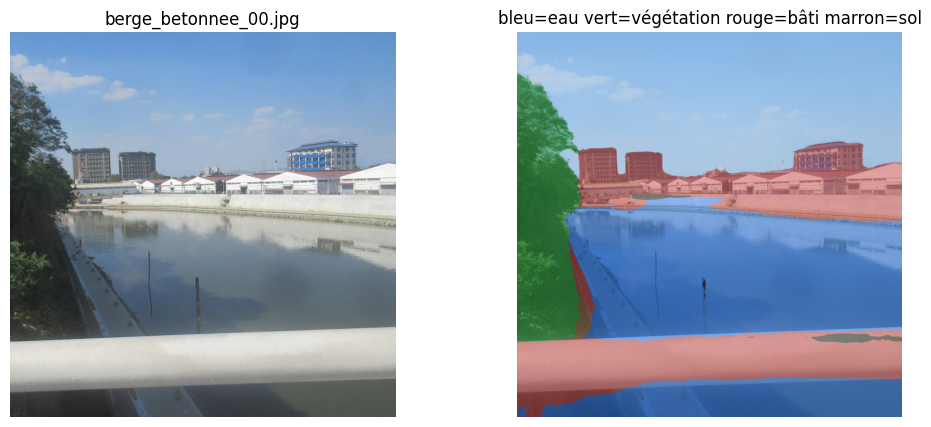

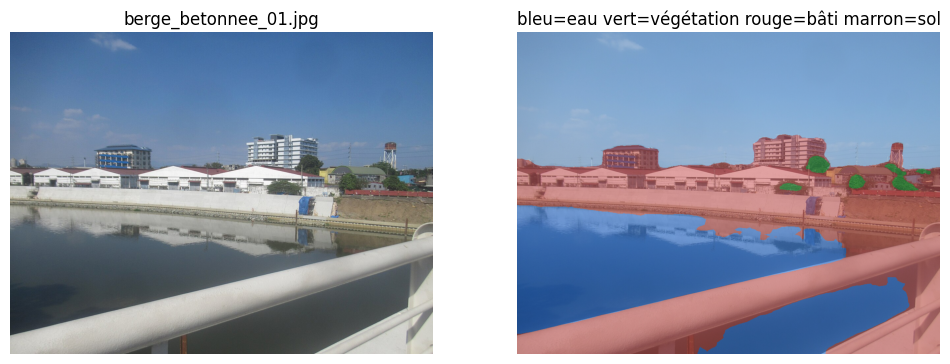

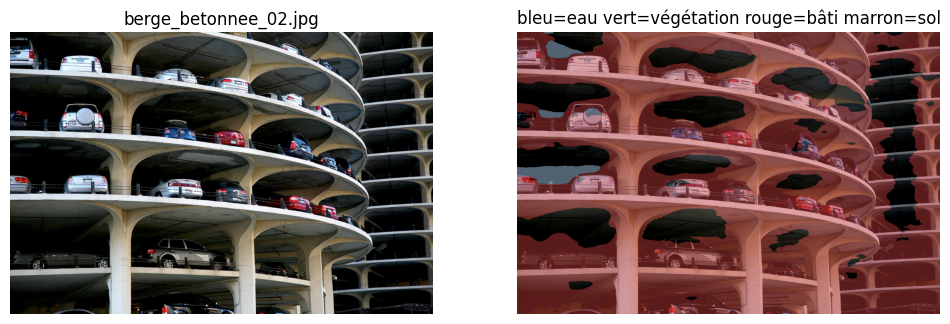

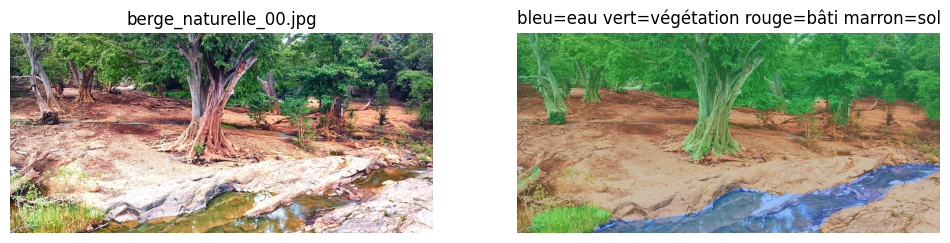

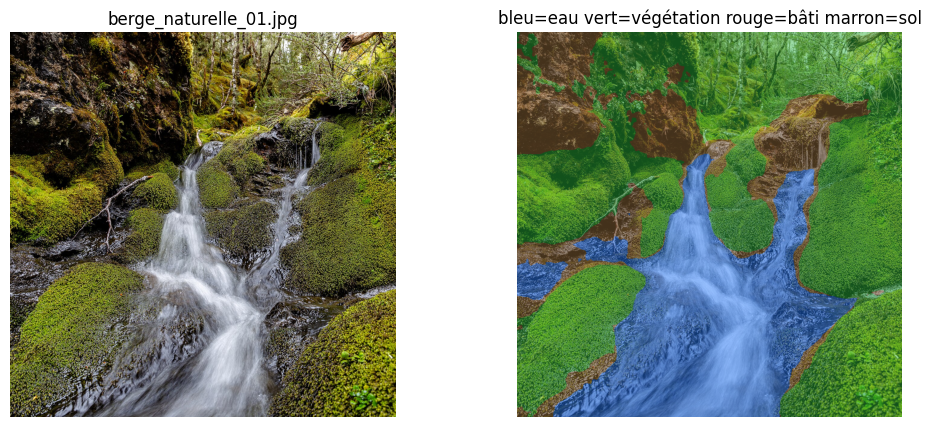

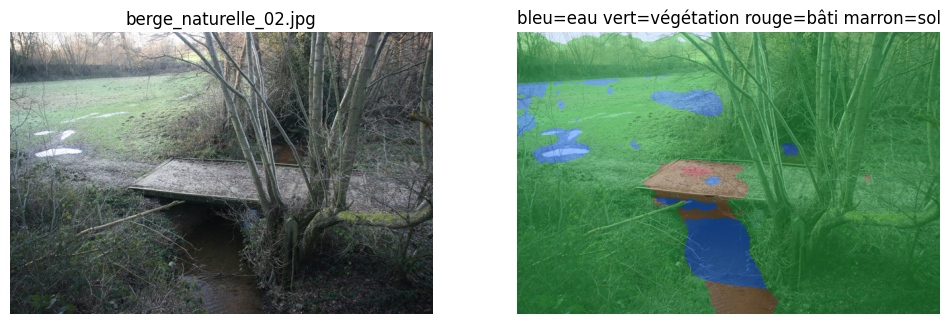

In [ ]:
import matplotlib.pyplot as plt

COULEURS = np.array([
    [0, 0, 0],        # autre
    [30, 120, 255],   # eau
    [40, 180, 60],    # végétation
    [200, 60, 60],    # bâti
    [150, 110, 60],   # sol naturel
    [180, 220, 255],  # ciel
], dtype=np.uint8)

def afficher(img_pil, masque, titre=""):
    superpose = (0.55 * np.array(img_pil) + 0.45 * COULEURS[masque]).astype(np.uint8)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(img_pil); ax[0].set_title(titre); ax[0].axis("off")
    ax[1].imshow(superpose); ax[1].set_title("bleu=eau vert=végétation rouge=bâti marron=sol"); ax[1].axis("off")
    plt.show()

photos_rivieres = [p for p in photos if "dechets" not in os.path.basename(p)]
for p in photos_rivieres[:6]:
  img = charger(p)
  afficher(img,segmenter(img),os.path.basename(p))

In [ ]:
def analyser_scene(masque):
    total = masque.size
    parts = {NOMS_GROUPES[g]: round(float((masque == g).sum()) / total, 3) for g in NOMS_GROUPES}

    eau = (masque == 1).astype(np.uint8)
    resultat = {"repartition": parts, "eau_visible": parts["eau"] >= 0.05}

    # Berge : anneau autour de l'eau (épaisseur ~3 % de la largeur)
    if resultat["eau_visible"]:
        k = max(5, masque.shape[1] // 33)
        anneau = cv2.dilate(eau, np.ones((k, k), np.uint8)) - eau
        zone = masque[anneau == 1]
        naturel = np.isin(zone, [2, 4]).sum()
        bati = (zone == 3).sum()
        if naturel + bati > 0:
            ratio_bati = bati / (naturel + bati)
            resultat["berge"] = {
                "type": "bétonnée" if ratio_bati > 0.6 else "mixte" if ratio_bati > 0.3 else "naturelle",
                "part_artificielle": round(float(ratio_bati), 2),
            }
        else:
            resultat["berge"] = {"type": "indéterminée", "part_artificielle": None}

    # Ombrage : végétation dans la moitié haute
    haut = masque[: masque.shape[0] // 2]
    ombrage = float((haut == 2).sum()) / haut.size
    resultat["ombrage"] = {
        "part_canopee": round(ombrage, 2),
        "niveau": "fort" if ombrage > 0.4 else "moyen" if ombrage > 0.15 else "faible",
    }
    return resultat

cellule sept


In [49]:
def analyser_eau(img_pil, masque):
    eau = (masque == 1)
    if eau.sum() < 0.05 * masque.size:
        return {"analyse_possible": False, "raison": "Eau pas assez visible : cadrez davantage le cours d'eau."}

    rgb = np.array(img_pil)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    gris = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    n = eau.sum()

    # Mousse : clair, peu coloré, plutôt lisse — seuils assouplis
    texture_locale = cv2.blur(np.abs(cv2.Laplacian(gris, cv2.CV_64F)), (15, 15))
    blanc = (eau & (s < 60) & (v > 175) & (texture_locale < 25)).astype(np.uint8)
    blanc = cv2.morphologyEx(blanc, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    part_mousse = blanc.sum() / n

    # Eau verte : on exige une teinte verte DOMINANTE et une eau peu texturée
    vert = eau & (h >= 30) & (h <= 90) & (s > 50) & (v > 40)
    part_vert = vert.sum() / n
    texture_eau = float(np.abs(cv2.Laplacian(gris, cv2.CV_64F))[eau].mean())
    eau_lisse = texture_eau < 25          # un reflet de feuillage est très texturé
    suspicion_vert = bool(part_vert > 0.18 and eau_lisse)

    # Turbidité (inchangée, elle fonctionne bien)
    brun = eau & (h >= 8) & (h <= 30) & (s > 50)
    part_brun = brun.sum() / n
    score_turbidite = float(np.clip(0.7 * part_brun + 0.3 * (1 - min(texture_eau / 20, 1)), 0, 1))

    # Irisation
    colores = eau & (s > 60) & (v > 80)
    irisation = 0.0
    if colores.sum() > 500:
        hf = h.astype(np.float32)
        gx = cv2.Sobel(hf, cv2.CV_32F, 1, 0); gy = cv2.Sobel(hf, cv2.CV_32F, 0, 1)
        irisation = float(((np.minimum(np.hypot(gx, gy), 180) > 60) & colores).sum() / n)

    return {
        "analyse_possible": True,
        "turbidite": {"score": round(score_turbidite, 2),
                      "niveau": "trouble" if score_turbidite > 0.5 else "légère" if score_turbidite > 0.25 else "claire"},
        "eau_verte": {"part": round(float(part_vert), 3), "texture_eau": round(texture_eau, 1),
                      "suspicion_efflorescence": suspicion_vert},
        "mousse": {"present": bool(part_mousse > 0.14), "couverture": round(float(part_mousse), 3)},
        "irisation": {"score": round(irisation, 3), "suspicion": bool(irisation > 0.12),
                      "a_confirmer": "test du bâton demandé" if irisation > 0.12 else None},
    }

cellule 8

In [50]:
import json
from tqdm.auto import tqdm

def pipeline_j1(chemin):
    img = charger(chemin)
    qualite = controle_qualite(img)
    resultat = {"photo": os.path.basename(chemin), "qualite": qualite}
    if not qualite["valide"]:
        resultat["photo_valide"] = False
        return resultat

    masque = segmenter(img)
    cv2.imwrite(f"{DOSSIERS['masques']}/{os.path.splitext(resultat['photo'])[0]}.png", masque)

    scene = analyser_scene(masque)
    resultat["photo_valide"] = scene["eau_visible"]
    resultat["scene"] = scene
    resultat["eau"] = analyser_eau(img, masque)
    return resultat

resultats = []
ignorees = []
for p in tqdm(photos):
    try:
        resultats.append(pipeline_j1(p))
    except Exception as e:
        ignorees.append((os.path.basename(p), type(e).__name__))

print(len(resultats), "photos analysées,", len(ignorees), "ignorées")
if ignorees:
    print("Ignorées :", ignorees)

with open(f"{DOSSIERS['resultats']}/resultats_j1.json", "w", encoding="utf-8") as f:
    json.dump(resultats, f, ensure_ascii=False, indent=2)

  0%|          | 0/51 [00:00<?, ?it/s]

51 photos analysées, 0 ignorées


In [51]:
import pandas as pd

lignes = []
for r in resultats:
    s, e = r.get("scene", {}), r.get("eau", {})
    lignes.append({
        "photo": r["photo"],
        "valide": r.get("photo_valide"),
        "eau_%": round(s.get("repartition", {}).get("eau", 0) * 100),
        "berge": s.get("berge", {}).get("type"),
        "ombrage": s.get("ombrage", {}).get("niveau"),
        "turbidite": e.get("turbidite", {}).get("niveau"),
        "eau_verte": e.get("eau_verte", {}).get("suspicion_efflorescence"),
        "mousse": e.get("mousse", {}).get("present"),
        "irisation": e.get("irisation", {}).get("suspicion"),
    })

tableau = pd.DataFrame(lignes)
display(tableau[~tableau["photo"].str.startswith("dechets")])

,photo,valide,eau_%,berge,ombrage,turbidite,eau_verte,mousse,irisation
0,berge_betonnee_00.jpg,True,35,bétonnée,faible,claire,False,False,False
1,berge_betonnee_01.jpg,True,24,bétonnée,faible,claire,False,False,False
2,berge_betonnee_02.jpg,False,0,None,faible,None,None,None,None
3,berge_naturelle_00.jpg,True,11,naturelle,fort,légère,False,False,False
4,berge_naturelle_01.jpg,True,26,naturelle,fort,claire,False,True,False
5,berge_naturelle_02.jpg,False,0,None,fort,None,None,None,None
36,eau_boueuse_00.jpg,True,34,mixte,fort,légère,False,False,False
37,eau_boueuse_01.jpg,True,30,naturelle,fort,trouble,False,False,False
38,eau_boueuse_02.jpg,False,0,None,faible,None,None,None,None
39,eau_verte_00.jpg,True,8,naturelle,faible,claire,False,False,False


In [ ]:
lignes = []
for r in resultats:
    e = r.get("eau", {})
    if not e.get("analyse_possible"):
      continue
    lignes.append({
        "photo": r["photo"],
        "part_vert": e["eau_verte"]["part"],
        "couv_mousse" : e["mousse"]["couverture"],
        "score_turb": e["turbidite"]["score"],
    })


In [52]:
for r in resultats:
    e = r.get("eau", {})
    if e.get("analyse_possible") and not r["photo"].startswith("dechets"):
        print(r["photo"], "| vert:", e["eau_verte"]["part"],
              "| mousse:", e["mousse"]["couverture"],
              "| turb:", e["turbidite"]["score"])

berge_betonnee_00.jpg | vert: 0.0 | mousse: 0.116 | turb: 0.15
berge_betonnee_01.jpg | vert: 0.0 | mousse: 0.007 | turb: 0.22
berge_naturelle_00.jpg | vert: 0.081 | mousse: 0.006 | turb: 0.39
berge_naturelle_01.jpg | vert: 0.015 | mousse: 0.149 | turb: 0.07
eau_boueuse_00.jpg | vert: 0.001 | mousse: 0.112 | turb: 0.41
eau_boueuse_01.jpg | vert: 0.001 | mousse: 0.101 | turb: 0.54
eau_verte_00.jpg | vert: 0.015 | mousse: 0.051 | turb: 0.0
eau_verte_02.jpg | vert: 0.193 | mousse: 0.086 | turb: 0.2
mousse_00.jpg | vert: 0.206 | mousse: 0.179 | turb: 0.13
mousse_01.jpg | vert: 0.0 | mousse: 0.162 | turb: 0.11
mousse_02.jpg | vert: 0.0 | mousse: 0.152 | turb: 0.1


## 9. Évaluation rapide

Créez `MyDrive/streamsentinel/annotations.csv` avec vos vérités terrain, par exemple :

```
photo,berge,turbidite,eau_verte,mousse
riviere_01.jpg,naturelle,claire,0,0
riviere_02.jpg,bétonnée,trouble,0,1
```

In [53]:
import csv

# Vérités terrain, déduites des noms de fichiers puis à corriger à la main
verites = {
    "berge_betonnee_00.jpg":  ("bétonnée",  "claire",  0, 0),
    "berge_betonnee_01.jpg":  ("bétonnée",  "claire",  0, 0),
    "berge_naturelle_00.jpg": ("naturelle", "claire",  0, 0),
    "berge_naturelle_01.jpg": ("naturelle", "claire",  0, 0),
    "eau_boueuse_00.jpg":     ("naturelle", "trouble", 0, 0),
    "eau_boueuse_01.jpg":     ("naturelle", "trouble", 0, 0),
    "eau_verte_00.jpg":       ("naturelle", "claire",  1, 0),
    "eau_verte_02.jpg":       ("naturelle", "claire",  1, 0),
    "mousse_00.jpg":          ("naturelle", "claire",  0, 1),
    "mousse_01.jpg":          ("naturelle", "claire",  0, 1),
    "mousse_02.jpg":          ("naturelle", "claire",  0, 1),
}

with open(f"{BASE}/annotations.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["photo", "berge", "turbidite", "eau_verte", "mousse"])
    for photo, (berge, turb, vert, mousse) in verites.items():
        w.writerow([photo, berge, turb, vert, mousse])

print(len(verites), "annotations écrites dans", f"{BASE}/annotations.csv")

11 annotations écrites dans /content/drive/MyDrive/streamsentinel/annotations.csv


In [54]:
import pandas as pd

chemin_csv = f"{BASE}/annotations.csv"
if os.path.exists(chemin_csv):
    verite = pd.read_csv(chemin_csv).set_index("photo")
    lignes = []
    for r in resultats:
        if r["photo"] not in verite.index or not r.get("eau", {}).get("analyse_possible"):
            continue
        v = verite.loc[r["photo"]]
        lignes.append({
            "berge_ok": r["scene"].get("berge", {}).get("type") == v["berge"],
            "turbidite_ok": r["eau"]["turbidite"]["niveau"] == v["turbidite"],
            "vert_ok": r["eau"]["eau_verte"]["suspicion_efflorescence"] == bool(v["eau_verte"]),
            "mousse_ok": r["eau"]["mousse"]["present"] == bool(v["mousse"]),
        })
    print((pd.DataFrame(lignes).mean() * 100).round(1).astype(str) + " %")
else:
    print("Pas encore d'annotations.csv : à créer pour mesurer la précision.")

berge_ok        90.9 %
turbidite_ok    81.8 %
vert_ok         90.9 %
mousse_ok       90.9 %
dtype: object


## 10. Roboflow : préparer les détecteurs d'objets (J3)

1. Sur roboflow.com, créez un projet **Object Detection** nommé `streamsentinel-detection`.
2. Définissez les classes (palier 1 puis 2) :
   `bouteille`, `sac_plastique`, `canette`, `emballage`, `poisson_mort`, `buse_rejet`.
3. Cherchez sur **Roboflow Universe** des jeux existants (« floating trash », « river litter », « drain pipe »)
   et clonez les images utiles dans votre projet, en vérifiant leur licence.
4. Envoyez vos propres photos avec la cellule ci-dessous.
5. Utilisez **Auto Label** (détection zero-shot) pour pré-annoter, puis **corrigez à la main**.

Mousse, eau verte, turbidité et irisation ne sont **pas** à annoter ici : le bloc 3 s'en charge.

In [ ]:
from roboflow import Roboflow

NOM_PROJET = "streamsentinel-detection"   # identifiant exact visible dans l'URL Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
projet = rf.workspace().project(NOM_PROJET)

for p in tqdm(photos):
    try:
        projet.upload(image_path=p, split="train", batch_name="photos_terrain_j1")
    except Exception as e:
        print("Échec :", os.path.basename(p), e)